In [39]:
import joblib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, precision_recall_curve

from transformers import Resampler, BandPassFilter, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor

from config import N_MELS

In [40]:
def show_precision_recall_curve(y_true, y_proba, punto_corte=0.5):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)

    plt.plot(thr, rec[:-1], label='recall')
    plt.plot(thr, prec[:-1], label='precision')
    plt.xlabel('Punto de corte')
    plt.vlines(punto_corte, 0, 1, colors='red', linestyles='dashed', label='corte')
    plt.grid()
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.legend()
    plt.show()

def show_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Matriz de Confusión');

## Pipelines

Se pueden probar la sustración espectral o wavelet denoising

In [41]:
pipeline_melspec = Pipeline([
    ('resampler', Resampler()),
    ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('padder', SpectrogramPadder()),
    ('flatten', FlattenTransformer())
])

pipeline_features = Pipeline([
    ('resampler', Resampler()),
    ('bandpass', BandPassFilter()),
    ('feature_extractor', FeatureExtractor())
])

## Audios de validación

### propios

In [42]:
path = './audios_propios/ciclos_energy_based'
files = os.listdir(path)

In [43]:
paths = [os.path.join(path, f) for f in files]

In [44]:
X_propios_melspec = pipeline_melspec.fit_transform(paths)

In [45]:
X_propios_features = pipeline_features.fit_transform(paths)

### coswara

Hay que segmentarlos!!!

In [46]:
dataset = 'ciclos_c_r_hl256'

# Espectrogramas

## Random Forest

In [47]:
test_data = np.load(f'./dataset/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [48]:
melspec_rf = joblib.load(f'./modelos/{dataset}/melspec_rf.pkl')

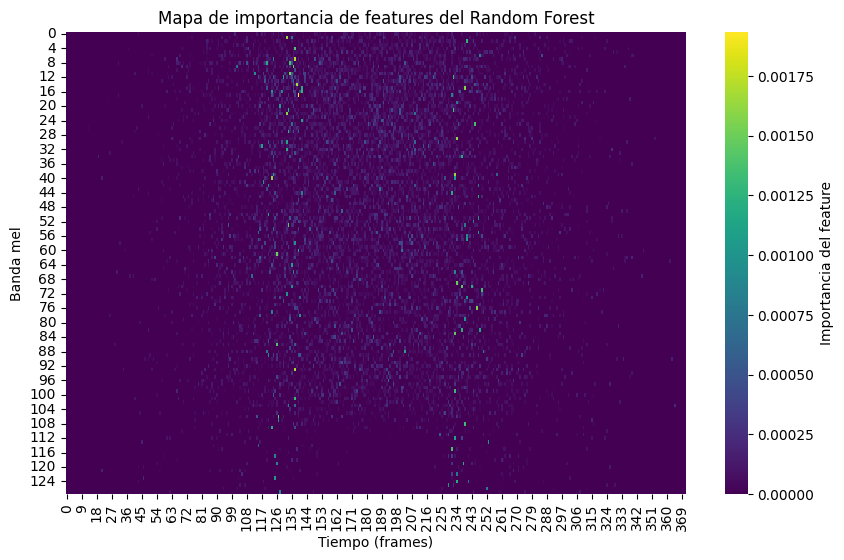

In [49]:
importances = melspec_rf.feature_importances_

n_mels = N_MELS
n_frames = importances.shape[0] // n_mels

importance_img = importances.reshape((n_mels, n_frames))

plt.figure(figsize=(10, 6))
sns.heatmap(
    importance_img,
    cmap='viridis',
    cbar_kws={'label': 'Importancia del feature'},
)
plt.xlabel("Tiempo (frames)")
plt.ylabel("Banda mel")
plt.title("Mapa de importancia de features del Random Forest")
plt.show()

In [50]:
y_pred = melspec_rf.predict(X_test)
y_pred_proba = melspec_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.57      0.62       663
           1       0.62      0.73      0.67       633

    accuracy                           0.65      1296
   macro avg       0.65      0.65      0.65      1296
weighted avg       0.65      0.65      0.64      1296



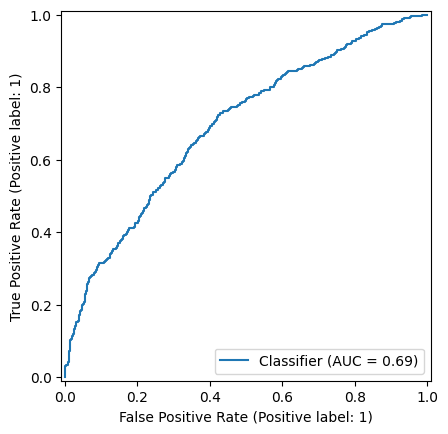

In [51]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

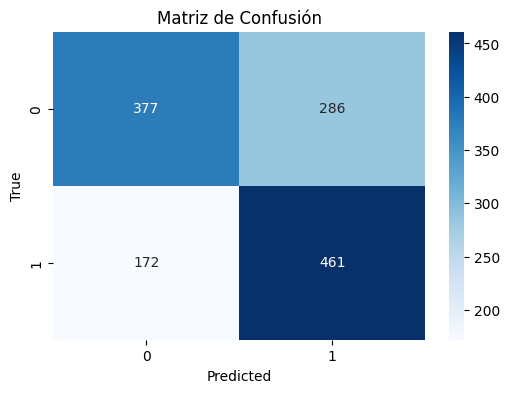

In [52]:
show_confusion_matrix(y_test, y_pred)

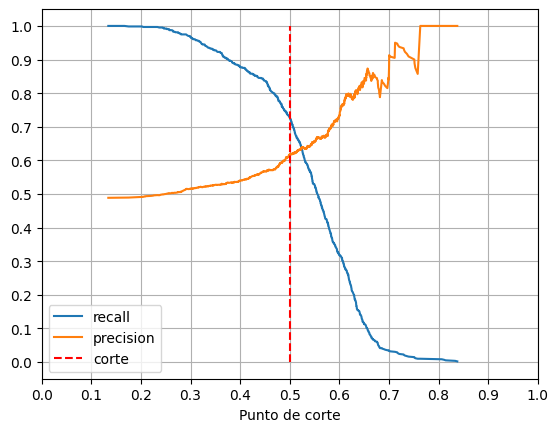

In [53]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

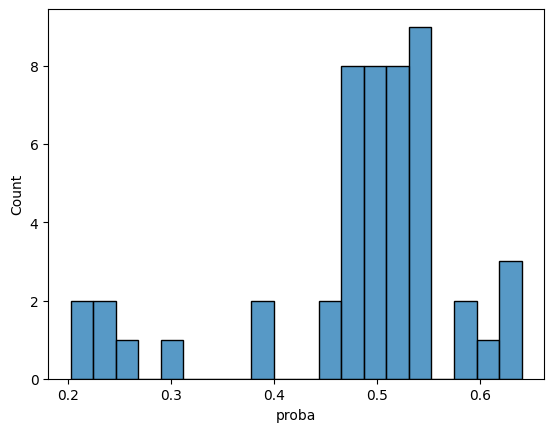

In [54]:
probas_propios = melspec_rf.predict_proba(X_propios_melspec)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})
sns.histplot(df_probas, x='proba', bins=20);

In [55]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.595667
1,respiracion1_ciclo_2.wav,0.234929
2,respiracion1_ciclo_3.wav,0.546765
3,respiracion1_ciclo_4.wav,0.395165
4,respiracion1_ciclo_5.wav,0.538022
5,respiracion1_ciclo_6.wav,0.468486
6,respiracion1_ciclo_7.wav,0.540197
7,respiracion2_ciclo_1.wav,0.471093
8,respiracion2_ciclo_2.wav,0.541873
9,respiracion2_ciclo_3.wav,0.536831


## Gradient Boosting Classifier

In [56]:
melspec_gbc = joblib.load(f'./modelos/{dataset}/melspec_gbc.pkl')

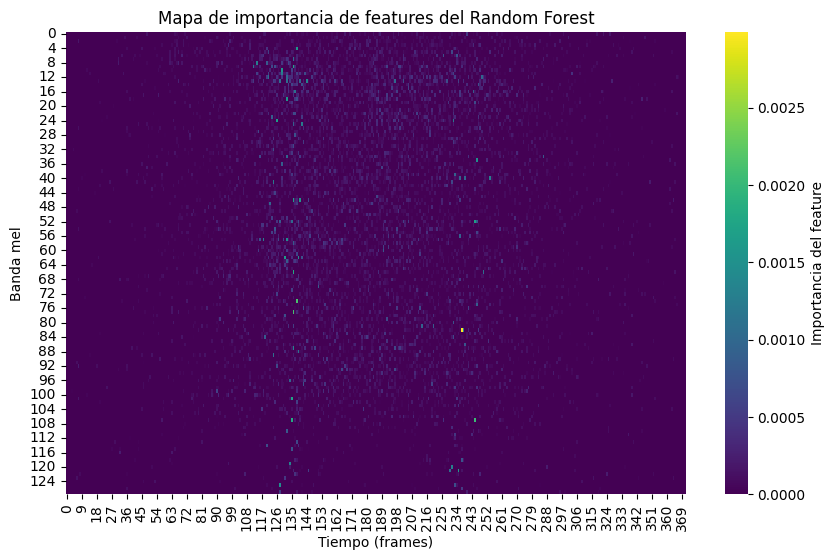

In [57]:
importances = melspec_gbc.feature_importances_

n_mels = N_MELS
n_frames = importances.shape[0] // n_mels

importance_img = importances.reshape((n_mels, n_frames))

plt.figure(figsize=(10, 6))
sns.heatmap(
    importance_img,
    cmap="viridis",
    cbar_kws={'label': 'Importancia del feature'},
)
plt.xlabel("Tiempo (frames)")
plt.ylabel("Banda mel")
plt.title("Mapa de importancia de features del Random Forest")
plt.show()

In [58]:
y_pred = melspec_gbc.predict(X_test)
y_pred_proba = melspec_gbc.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.59      0.63       663
           1       0.62      0.71      0.66       633

    accuracy                           0.64      1296
   macro avg       0.65      0.65      0.64      1296
weighted avg       0.65      0.64      0.64      1296



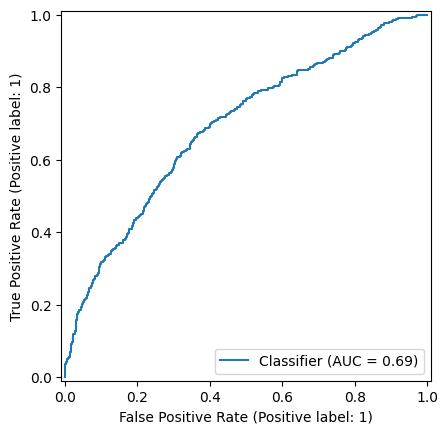

In [59]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

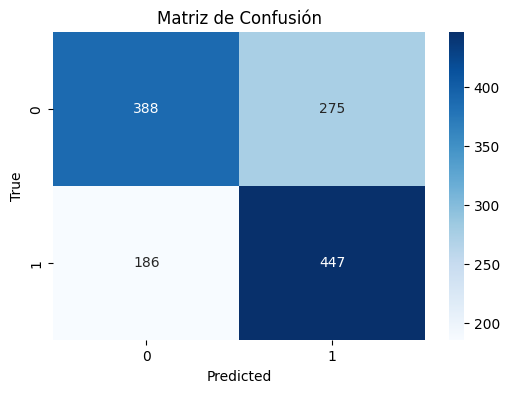

In [60]:
show_confusion_matrix(y_test, y_pred)

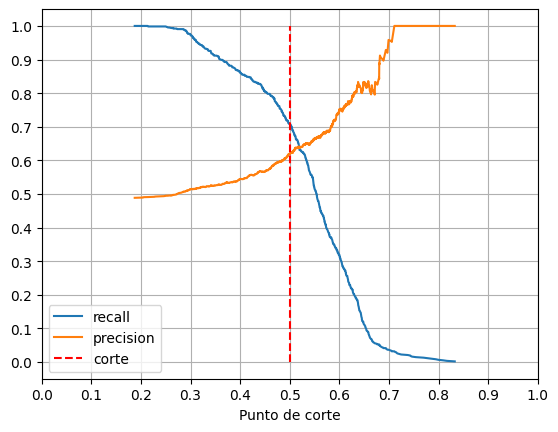

In [61]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

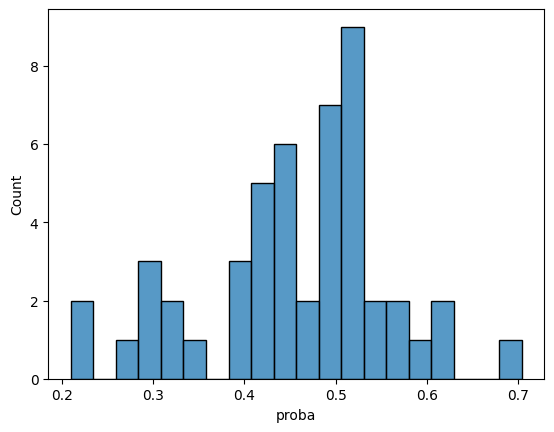

In [62]:
probas_propios = melspec_gbc.predict_proba(X_propios_melspec)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})
sns.histplot(df_probas, x='proba', bins=20);

In [63]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.574545
1,respiracion1_ciclo_2.wav,0.284007
2,respiracion1_ciclo_3.wav,0.490061
3,respiracion1_ciclo_4.wav,0.324803
4,respiracion1_ciclo_5.wav,0.515825
5,respiracion1_ciclo_6.wav,0.403000
6,respiracion1_ciclo_7.wav,0.520778
7,respiracion2_ciclo_1.wav,0.400152
8,respiracion2_ciclo_2.wav,0.518246
9,respiracion2_ciclo_3.wav,0.509429


# Features

## Random Forest

In [64]:
test_data = np.load(f'./dataset/{dataset}/test_features.npz')
X_test = test_data['X']
y_test = test_data['y']

In [65]:
feat_rf = joblib.load(f'./modelos/{dataset}/features_rf.pkl')

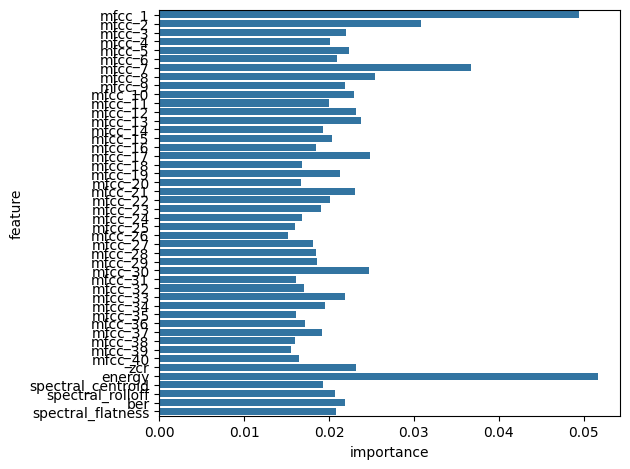

In [66]:
importances = feat_rf.feature_importances_
columns = ['mfcc_' + str(i) for i in range(1, 41)] + ['zcr', 'energy', 'spectral_centroid', 'spectral_rolloff', 'ber', 'spectral_flatness']

importance_df = pd.DataFrame({
    'feature': columns,
    'importance': importances
})
sns.barplot(data=importance_df, x='importance', y='feature')
plt.tight_layout();

In [67]:
y_pred = feat_rf.predict(X_test)
y_pred_proba = feat_rf.predict_proba(X_test)[:, 1]

In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       663
           1       0.75      0.74      0.74       633

    accuracy                           0.75      1296
   macro avg       0.75      0.75      0.75      1296
weighted avg       0.75      0.75      0.75      1296



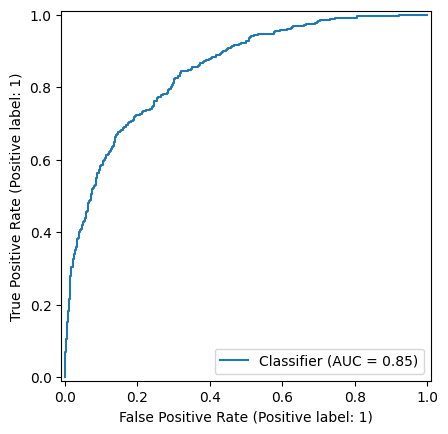

In [69]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

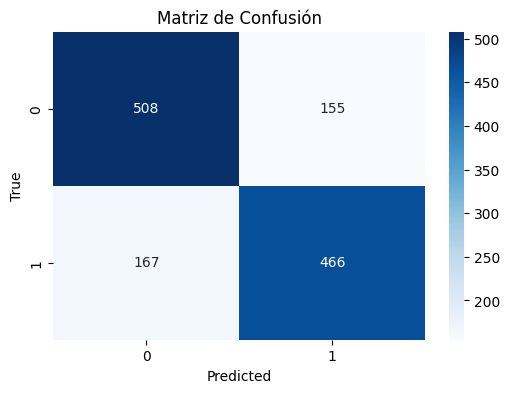

In [70]:
show_confusion_matrix(y_test, y_pred)

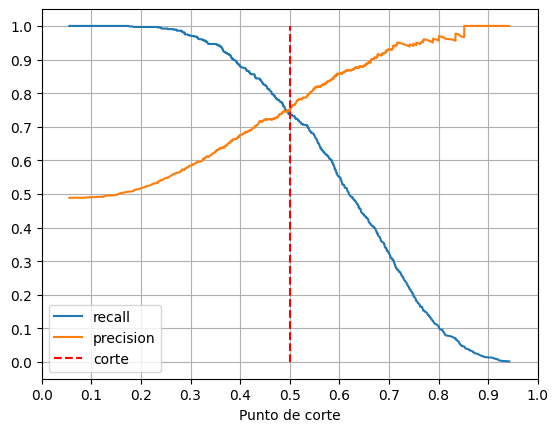

In [71]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

In [72]:
probas_propios = feat_rf.predict_proba(X_propios_features)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})

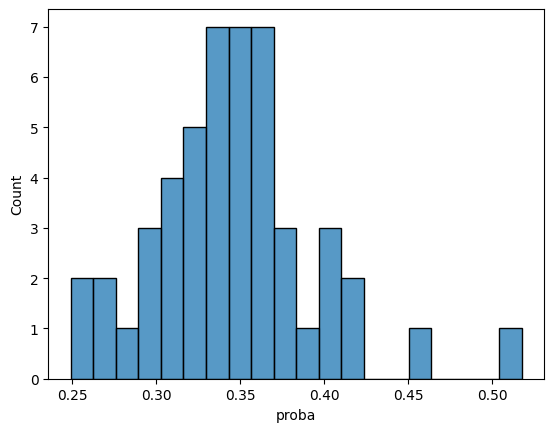

In [73]:
sns.histplot(df_probas, x='proba', bins=20);

In [74]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.271426
1,respiracion1_ciclo_2.wav,0.324008
2,respiracion1_ciclo_3.wav,0.345402
3,respiracion1_ciclo_4.wav,0.338976
4,respiracion1_ciclo_5.wav,0.350901
5,respiracion1_ciclo_6.wav,0.349030
6,respiracion1_ciclo_7.wav,0.322881
7,respiracion2_ciclo_1.wav,0.368636
8,respiracion2_ciclo_2.wav,0.342407
9,respiracion2_ciclo_3.wav,0.358579
